Using file: POWER_Point_Hourly_20230101_20231231_025d28N_051d53E_LST.csv
count    8760.000000
mean       28.502223
std         8.080496
min        10.050000
25%        21.610000
50%        28.580000
75%        34.070000
max        46.520000
Name: T2M, dtype: float64
Plain: 1057 kWh/yr, Insulated: 264 kWh/yr
Reduction: 75%


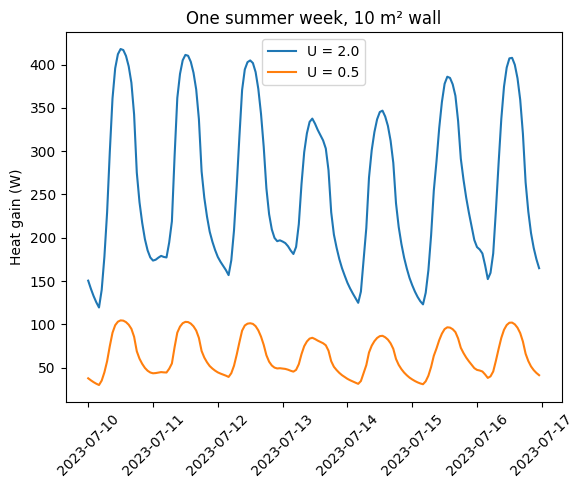

In [3]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

# find the uploaded NASA file automatically
f = glob.glob("POWER_Point_Hourly*.csv")[0]
print("Using file:", f)

df = pd.read_csv(f, skiprows=10)
df["time"] = pd.to_datetime(dict(year=df.YEAR, month=df.MO, day=df.DY, hour=df.HR))

print(df.T2M.describe())

A, T_in = 10, 24  # wall area (m2), indoor setpoint (C)

def heat_gain(U):
    return (U * A * (df.T2M - T_in)).clip(lower=0)

q_plain = heat_gain(2.0)
q_insul = heat_gain(0.5)

kwh_plain = q_plain.sum() / 1000
kwh_insul = q_insul.sum() / 1000
print(f"Plain: {kwh_plain:.0f} kWh/yr, Insulated: {kwh_insul:.0f} kWh/yr")
print(f"Reduction: {100 * (1 - kwh_insul / kwh_plain):.0f}%")

week = (df.time >= "2023-07-10") & (df.time < "2023-07-17")
plt.plot(df.time[week], q_plain[week], label="U = 2.0")
plt.plot(df.time[week], q_insul[week], label="U = 0.5")
plt.ylabel("Heat gain (W)")
plt.legend()
plt.title("One summer week, 10 m² wall")
plt.xticks(rotation=45)
plt.show()

Dark roof: 21700 kWh/yr
White coated roof: 13454 kWh/yr
Reduction: 38%


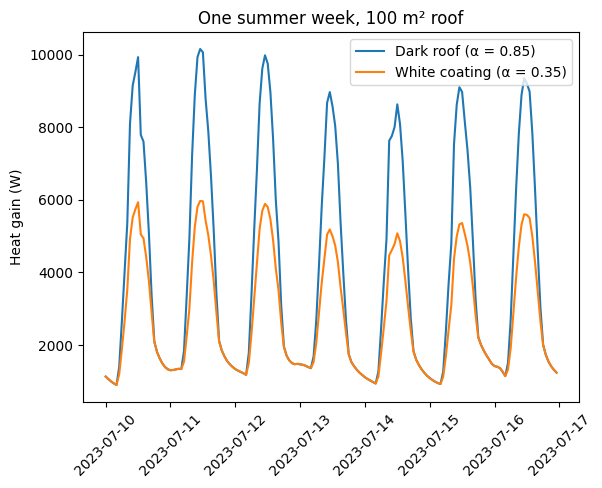

In [4]:
# --- Roof model with solar heating (sol-air temperature) ---
A_roof = 100     # roof area (m2)
U_roof = 1.5     # roof U-value (W/m2.K), uninsulated concrete roof (assumption)
h_o = 17         # outside heat-transfer coefficient (W/m2.K)
T_in = 24        # indoor setpoint (C)

def roof_gain(absorptance):
    T_sol_air = df.T2M + absorptance * df.ALLSKY_SFC_SW_DWN / h_o
    return (U_roof * A_roof * (T_sol_air - T_in)).clip(lower=0)

q_dark = roof_gain(0.85)   # dark / bare roof
q_white = roof_gain(0.35)  # reflective white coating

kwh_dark = q_dark.sum() / 1000
kwh_white = q_white.sum() / 1000
print(f"Dark roof: {kwh_dark:.0f} kWh/yr")
print(f"White coated roof: {kwh_white:.0f} kWh/yr")
print(f"Reduction: {100 * (1 - kwh_white / kwh_dark):.0f}%")

week = (df.time >= "2023-07-10") & (df.time < "2023-07-17")
plt.plot(df.time[week], q_dark[week], label="Dark roof (α = 0.85)")
plt.plot(df.time[week], q_white[week], label="White coating (α = 0.35)")
plt.ylabel("Heat gain (W)")
plt.title("One summer week, 100 m² roof")
plt.legend()
plt.xticks(rotation=45)
plt.show()